In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform, color, util
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

# Zadanie 1

In [20]:
print(f"Oryginalny rozmiar: {cat_image .shape}")

cat_image = data.chelsea()
h, w, _ = cat_image.shape
print(f"Oryginalny rozmiar: {cat_image.shape}")

Oryginalny rozmiar: (300, 451, 3)
Oryginalny rozmiar: (300, 451, 3)


In [21]:
min_dim = min(h, w)
start_h = (h - min_dim) // 2
start_w = (w - min_dim) // 2

In [22]:
cropped_image = cat_image[start_h:start_h + min_dim, start_w:start_w + min_dim]
image_resized = transform.resize(cropped_image, (128, 128), anti_aliasing=True)

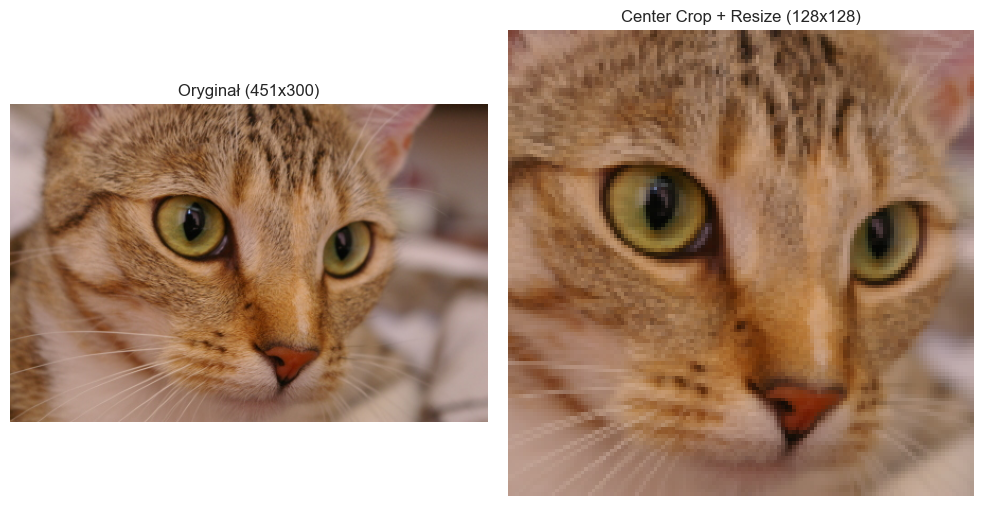

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(cat_image)
ax[0].set_title(f"Oryginał ({w}x{h})")
ax[0].axis('off')

ax[1].imshow(image_resized)
ax[1].set_title("Center Crop + Resize (128x128)")
ax[1].axis('off')

plt.tight_layout()
plt.show()

# Zadanie 2

In [24]:
astronaut_image = data.astronaut()
astronaut_resized = transform.resize(astronaut_image, (128, 128), anti_aliasing=True)

In [25]:
astronaut_gray = color.rgb2gray(astronaut_resized)
astronaut_vector = astronaut_gray.flatten()
print(f"Kształt wektora po spłaszczeniu: {astronaut_vector.shape}")

Kształt wektora po spłaszczeniu: (16384,)


# Zadanie 3

In [26]:
scaler = StandardScaler()
astronaut_standardized = scaler.fit_transform(astronaut_vector.reshape(-1, 1)).flatten()


In [27]:
print(f"Średnia po standaryzacji: {astronaut_standardized.mean():.2f}")
print(f"Odchylenie std po standaryzacji: {astronaut_standardized.std():.2f}")
print(f"Zakres wartości: od {astronaut_standardized.min():.2f} do {astronaut_standardized.max():.2f}")


Średnia po standaryzacji: 0.00
Odchylenie std po standaryzacji: 1.00
Zakres wartości: od -1.55 do 1.95


# Zadanie 4

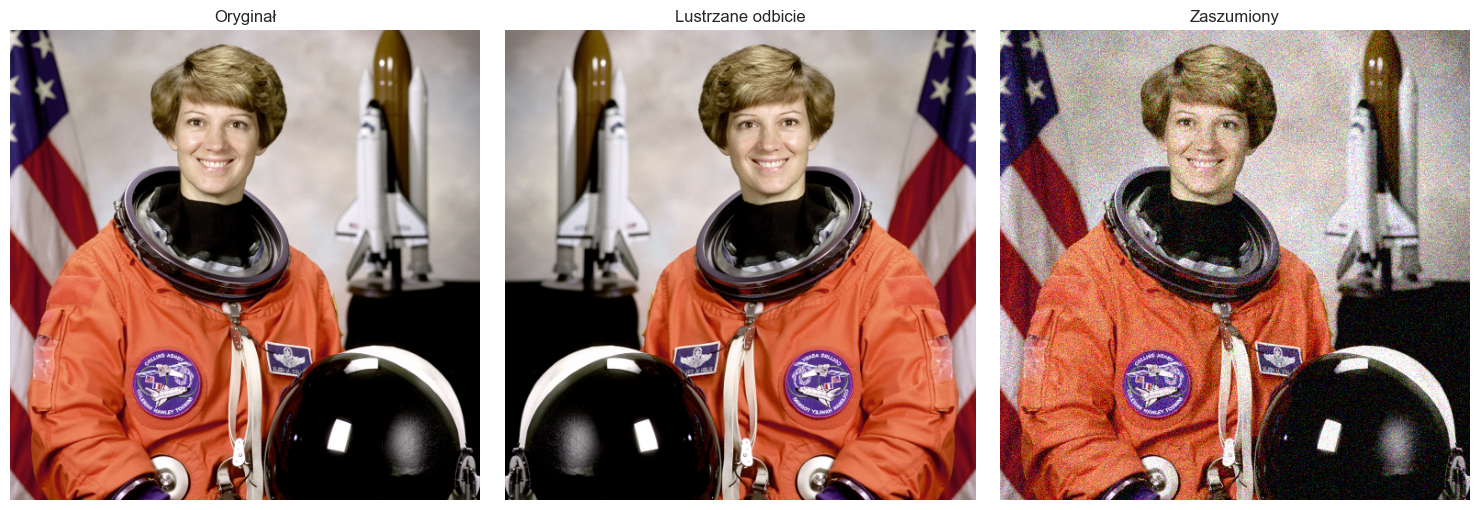

In [28]:
astronaut_image = data.astronaut()

astronaut_flipped = astronaut_image[:, ::-1, :]

astronaut_noisy = util.random_noise(astronaut_image)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(astronaut_image)
ax[0].set_title('Oryginał')
ax[0].axis('off')

ax[1].imshow(astronaut_flipped)
ax[1].set_title('Lustrzane odbicie')
ax[1].axis('off')

ax[2].imshow(astronaut_noisy)
ax[2].set_title('Zaszumiony')
ax[2].axis('off')

plt.tight_layout()
plt.show()


# Zadanie 5


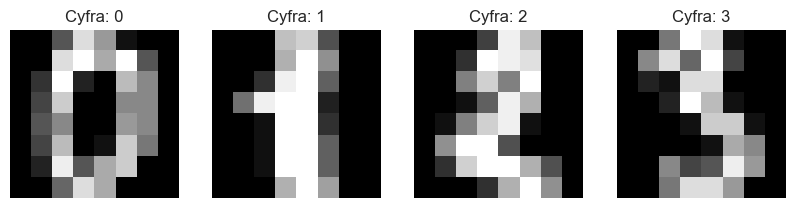

In [29]:
digits = load_digits()
X = digits.data

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for i in range(4):
    axes[i].imshow(X[i].reshape(8, 8), cmap='gray')
    axes[i].set_title(f"Cyfra: {digits.target[i]}")
    axes[i].axis('off')
plt.show()


Oryginalnie mieliśmy 64 cechy (piksele 8x8).
Liczba zachowanych komponentów (by zatrzymać 90% wariancji): 21


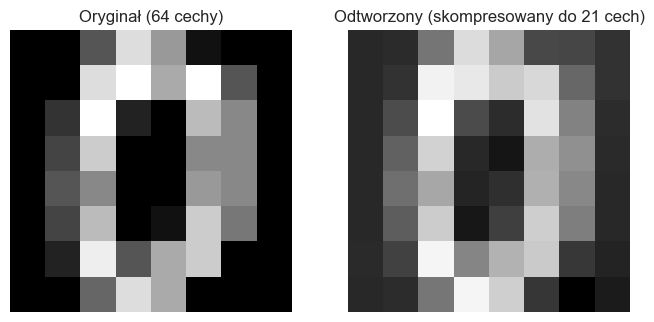

In [30]:
pca = PCA(n_components=0.90)

X_pca = pca.fit_transform(X)

print(f"Oryginalnie mieliśmy 64 cechy (piksele 8x8).")
print(f"Liczba zachowanych komponentów (by zatrzymać 90% wariancji): {pca.n_components_}")

X_recovered = pca.inverse_transform(X_pca)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(X[0].reshape(8, 8), cmap='gray')
ax[0].set_title('Oryginał (64 cechy)')
ax[0].axis('off')

ax[1].imshow(X_recovered[0].reshape(8, 8), cmap='gray')
ax[1].set_title(f'Odtworzony (skompresowany do {pca.n_components_} cech)')
ax[1].axis('off')

plt.show()


# Zadanie 6


In [31]:
import os
from skimage import io

def flipper(img, prob=0.5):
    if np.random.rand() < prob:
        return np.fliplr(img)
    return img

def gray_filterer(img, prob=0.5):
    if np.random.rand() < prob:
        if img.ndim == 2:
            return img
        if img.ndim == 3 and img.shape[2] == 4:
            img = color.rgba2rgb(img)
        return color.rgb2gray(img)
    return img

def preprocess_images(img_list, target_size, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    for img_name in img_list:
        img = eval(f'data.{img_name}()')

        h, w = img.shape[:2]

        if h != w:
            min_dim = min(h, w)
            start_h = (h - min_dim) // 2
            start_w = (w - min_dim) // 2
            img = img[start_h:start_h + min_dim, start_w:start_w + min_dim]

        if img.shape[:2] != target_size:
            img = transform.resize(img, target_size, anti_aliasing=True)

        img = flipper(img, prob=0.5)
        img = gray_filterer(img, prob=0.5)

        img_to_save = util.img_as_ubyte(img)

        save_path = os.path.join(output_dir, f'{img_name}_processed.jpg')
        io.imsave(save_path, img_to_save)
        print(f'Przetworzono i zapisano: {save_path}')

img_list = ['rocket', 'astronaut', 'retina', 'grass', 'camera', 'cat', 'coffee']
preprocess_images(img_list, target_size=(128, 128), output_dir='data/processed_images')
print("Koniec")


Przetworzono i zapisano: data/processed_images\rocket_processed.jpg
Przetworzono i zapisano: data/processed_images\astronaut_processed.jpg
Przetworzono i zapisano: data/processed_images\retina_processed.jpg
Przetworzono i zapisano: data/processed_images\grass_processed.jpg
Przetworzono i zapisano: data/processed_images\camera_processed.jpg
Przetworzono i zapisano: data/processed_images\cat_processed.jpg
Przetworzono i zapisano: data/processed_images\coffee_processed.jpg
Koniec
